# 0. Notebook 2 — Treinamento, Validação Cruzada e Otimização de Hiperparâmetros

## 1. Visão Geral
### Nesta etapa, focamos no treinamento e na busca pelos melhores hiperparâmetros para o classificador (**LinearSVC**), utilizando um pipeline integrado de vetorização TF-IDF e Validação Cruzada Estratificada para garantir robustez e evitar *data leakage*.

In [1]:
import os
import joblib
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


## 2. Carga dos Dados de Treino e Tratamento de Rótulos

### Carregamento do arquivo `train.csv` e conversão segura dos rótulos textuais para inteiros (`0` e `1`), garantindo compatibilidade total com o NumPy e o `StratifiedKFold`.

In [2]:
# Definir caminhos com suporte a diferentes estruturas de diretórios
train_path = "data/processed/train.csv"
if not os.path.exists(train_path):
    train_path = "../../data/processed/train.csv"

df_train = pd.read_csv(train_path).dropna(subset=['texto_limpo'])
X_train = df_train['texto_limpo'].astype(str).values

# Identificar coluna alvo dinamicamente
coluna_classe = next((col for col in df_train.columns if col.lower() in ['classe', 'class', 'target', 'label', 'rotulo']), None)
if not coluna_classe:
    raise KeyError(f"Coluna de classe não encontrada. Colunas disponíveis: {df_train.columns.tolist()}")

# Conversão segura de rótulos textuais para índices inteiros e blindagem de arrays
y_raw = df_train[coluna_classe]
y_train, unique_classes = pd.factorize(y_raw)
y_train = np.ascontiguousarray(y_train, dtype=int)
X_train = np.ascontiguousarray(X_train)

print(f"• Amostras de treino carregadas: {len(X_train)}")
print(f"• Rótulos mapeados com sucesso: {dict(enumerate(unique_classes))}")

• Amostras de treino carregadas: 9216
• Rótulos mapeados com sucesso: {0: 1.0, 1: 0.0}


## 3. Configuração do Pipeline e do GridSearchCV

### Montagem do fluxo contendo o `TfidfVectorizer` e o `LinearSVC`, seguido pelas configurações da validação cruzada estratificada e espaço de busca de hiperparâmetros.

In [3]:
# Pipeline integrado de Texto + Modelo (garante que o TF-IDF recalcule a cada fold)
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
    ('clf', LinearSVC(random_state=42, dual='auto', max_iter=2000))
])

# Estratégia de validação cruzada estratificada (5 dobras)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grade de hiperparâmetros para otimização
param_grid = {
    'tfidf__max_df': [0.85, 1.0],
    'tfidf__min_df': [1, 2],
    'clf__C': [0.1, 1.0, 10.0]
}

# Configuração do GridSearchCV maximizando o F1-Macro
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print("✅ Pipeline e GridSearch configurados com sucesso!")

✅ Pipeline e GridSearch configurados com sucesso!


## 4. Execução do Treinamento e Otimização

### Execução do processo de ajuste (*fit*) utilizando todas as CPUs disponíveis (`n_jobs=-1`).

In [4]:
print("🚀 Iniciando a Validação Cruzada com GridSearch...")
grid_search.fit(X_train, y_train)

print(f"\n✨ Melhores Hiperparâmetros encontrados:\n{grid_search.best_params_}")
print(f"🎯 Melhor F1-Macro médio na Validação Cruzada: {grid_search.best_score_:.4f}")

🚀 Iniciando a Validação Cruzada com GridSearch...
Fitting 5 folds for each of 12 candidates, totalling 60 fits



✨ Melhores Hiperparâmetros encontrados:
{'clf__C': 10.0, 'tfidf__max_df': 0.85, 'tfidf__min_df': 1}
🎯 Melhor F1-Macro médio na Validação Cruzada: 0.9366


## 5. Exportação do Melhor Modelo Treinado

### Salvamento do estimador final otimizado (`best_estimator_`) no diretório de modelos do projeto.

In [5]:
# Criar diretório de modelos caso não exista
model_dir = "../../models" if os.path.exists("../../data") else "models"
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, "best_linearsvc_model.joblib")

# Serializar e salvar o pipeline completo (TF-IDF + LinearSVC otimizado)
joblib.dump(grid_search.best_estimator_, model_path)

print(f"💾 Melhor modelo salvo com sucesso em: '{model_path}'")
print("🚀 Notebook 02 concluído com sucesso!")

💾 Melhor modelo salvo com sucesso em: '../../models\best_linearsvc_model.joblib'
🚀 Notebook 02 concluído com sucesso!


## 6. Interpretabilidade do Modelo (Análise de Coeficientes)

### Como estamos utilizando o **LinearSVC**, uma das maiores vantagens é a interpretabilidade. Podemos extrair os coeficientes (`coef_`) associados a cada palavra do vocabulário (TF-IDF) para descobrir quais termos possuem maior peso na decisão do classificador.

In [6]:
# 1. Recuperar o melhor modelo treinado do Pipeline
melhor_modelo = grid_search.best_estimator_

# 2. Extrair o vetorizador e o classificador de dentro do pipeline
vectorizer = melhor_modelo.named_steps["tfidf"]
classifier = melhor_modelo.named_steps["clf"]

# 3. Pegar os nomes das palavras (features) e os coeficientes do LinearSVC
feature_names = vectorizer.get_feature_names_out()
coefs = classifier.coef_[
    0
]  # Coeficientes do classificador binário linear

# 4. Encontrar as palavras que mais puxam para cada polaridade
top_positive_idx = coefs.argsort()[-15:][::-1]  # Maiores pesos
top_negative_idx = coefs.argsort()[:15]  # Menores pesos (pesos negativos)

print("🔍 Top 15 palavras com maior peso positivo:")
for idx in top_positive_idx:
  print(f"  • {feature_names[idx]}: {coefs[idx]:.4f}")

print("\n🔍 Top 15 palavras com maior peso negativo:")
for idx in top_negative_idx:
  print(f"  • {feature_names[idx]}: {coefs[idx]:.4f}")

🔍 Top 15 palavras com maior peso positivo:
  • boato: 15.3882
  • fake: 10.3506
  • falso: 4.3959
  • vídeo: 3.9533
  • verdade: 3.6773
  • parir: 3.3710
  • foto: 3.2729
  • umar: 2.9277
  • engana: 2.0580
  • enganoso: 2.0487
  • montagem: 2.0384
  • falsa: 1.9390
  • post: 1.9356
  • contrário: 1.9345
  • disse: 1.8898

🔍 Top 15 palavras com maior peso negativo:
  • diz: -3.5036
  • coronavírus: -2.0494
  • fake news: -1.8074
  • veja: -1.6432
  • italiano contra: -1.5293
  • news: -1.5088
  • pede: -1.4964
  • pode: -1.4482
  • aponta: -1.4461
  • deve: -1.3780
  • pandemia: -1.3778
  • aprova: -1.3774
  • confirma: -1.3679
  • saúde: -1.3541
  • volta: -1.3454


### 📊 Visualização dos Coeficientes (Feature Importance)

#### O gráfico abaixo exibe os termos de maior impacto na decisão do classificador linear. Termos em **azul** puxam a classificação para um sentido, enquanto os termos em **vermelho** puxam para o oposto, revelando o padrão semântico aprendido pelo modelo.

C:\Users\LAISA\AppData\Local\Temp\ipykernel_19808\3782179352.py:65: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\LAISA\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


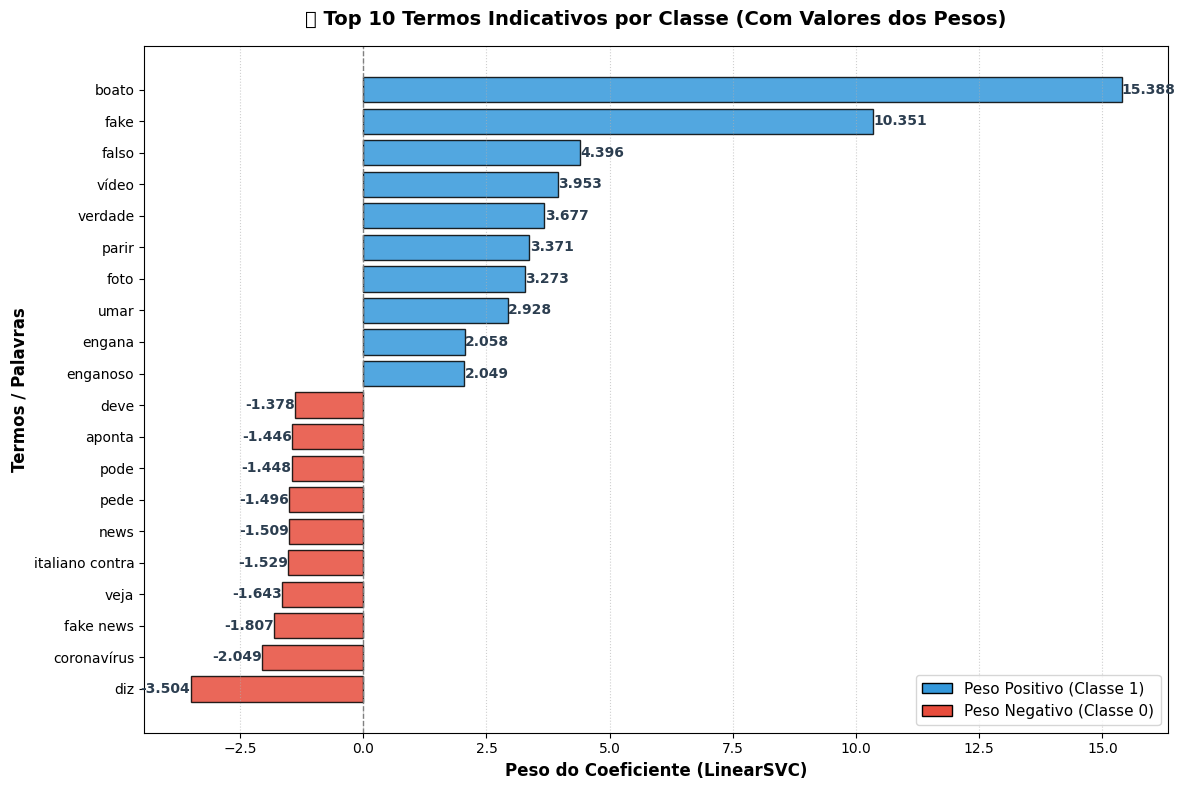

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Criar um DataFrame com todas as palavras e seus respectivos coeficientes
df_coef = pd.DataFrame({"Palavra": feature_names, "Coeficiente": coefs})

# 2. Selecionar as 10 palavras com maior peso e as 10 com menor peso
top_positivas = df_coef.nlargest(10, "Coeficiente")
top_negativas = df_coef.nsmallest(10, "Coeficiente")

# Juntar e ordenar para a visualização correta no gráfico de barras horizontais
df_plot = pd.concat([top_negativas, top_positivas]).sort_values(
    by="Coeficiente", ascending=True
)

# 3. Configurar e plotar o gráfico
plt.figure(figsize=(12, 8))

# Cores dinâmicas: azul para positivo, vermelho para negativo
cores = ["#e74c3c" if c < 0 else "#3498db" for c in df_plot["Coeficiente"]]

barras = plt.barh(
    df_plot["Palavra"], df_plot["Coeficiente"], color=cores, edgecolor="black", alpha=0.85
)

# 4. Adicionar os números (valores dos coeficientes) diretamente nas barras
for barra in barras:
  largura = barra.get_width()
  # Define o deslocamento e alinhamento com base no sinal do coeficiente
  offset = 0.005 if largura >= 0 else -0.005
  ha_align = "left" if largura >= 0 else "right"

  plt.text(
      largura + offset,
      barra.get_y() + barra.get_height() / 2,
      f"{largura:.3f}",
      va="center",
      ha=ha_align,
      fontsize=10,
      fontweight="bold",
      color="#2c3e50",
  )

# Personalização estética do gráfico
plt.axvline(x=0, color="grey", linestyle="--", linewidth=1)
plt.xlabel("Peso do Coeficiente (LinearSVC)", fontsize=12, fontweight="bold")
plt.ylabel("Termos / Palavras", fontsize=12, fontweight="bold")
plt.title(
    "🔍 Top 10 Termos Indicativos por Classe (Com Valores dos Pesos)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

# Adicionar legenda personalizada
from matplotlib.patches import Patch

legenda_elementos = [
    Patch(facecolor="#3498db", edgecolor="black", label="Peso Positivo (Classe 1)"),
    Patch(facecolor="#e74c3c", edgecolor="black", label="Peso Negativo (Classe 0)"),
]
plt.legend(handles=legenda_elementos, loc="lower right", fontsize=11)

plt.grid(axis="x", linestyle=":", alpha=0.6)
plt.tight_layout()

# Exibir o gráfico no Jupyter Notebook
plt.show()